In [28]:
import numpy as np
import pandas as pd
import nltk
from sklearn import preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import matplotlib
from matplotlib import pyplot as pyplot


In [29]:
df = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None
)

In [30]:
df.head(10)

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


In [31]:
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

In [32]:
df.head(5)

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [33]:
df.shape

(1600000, 6)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   target  1600000 non-null  int64
 1   ids     1600000 non-null  int64
 2   date    1600000 non-null  str  
 3   flag    1600000 non-null  str  
 4   user    1600000 non-null  str  
 5   text    1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 73.2 MB


In [35]:
df=df[['target','text']]

In [36]:
df['target']=df['target'].replace(4,1)

In [37]:
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [38]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JEENA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JEENA\AppData\Roaming\nltk_data...


True

In [39]:
from nltk.stem import WordNetLemmatizer
stop_words=set(stopwords.words("english"))
lemmatizer=WordNetLemmatizer()

In [40]:
import re
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r"http\S+|www\S+|http\S+","",text,flags=re.MULTILINE)
    text=re.sub(r"\@\w+|\#",'',text)
    text=re.sub(r"[^\w\s]","",text)
    words=[lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)

In [41]:
df['clean_text']=df["text"].apply(clean_text)
df.head()

,target,text,clean_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",thats bummer shoulda got david carr third day
1,0,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,0,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save 50 rest go b...
3,0,my whole body feels itchy and like its on fire,whole body feel itchy like fire
4,0,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see


In [43]:
sample=df.sample(1).iloc[0]
print("Original Text (Raw): ",sample["text"])
print("Cleaned Text: ",sample["clean_text"])

Original Text (Raw):  @pindec you need to follow me so I can reply 
Cleaned Text:  need follow reply


In [44]:
df=df.dropna(subset=["clean_text"])

In [46]:
X_train,X_test,y_train,y_test=train_test_split(df["clean_text"],df['target'],test_size=0.2,random_state=42)

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(max_features=10000)
X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)

In [49]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000,n_jobs=-1)
model.fit(X_train_tfidf, y_train)

c:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None


In [50]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test_tfidf)
accuracy=accuracy_score(y_test,y_pred)


In [ ]:
from sklearn.metrics import classification_report
print(f"Text Sentiment Analysis Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 50)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Text Sentiment Analysis Model Accuracy: 77.78%
--------------------------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.76      0.77    159494
           1       0.77      0.80      0.78    160506

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



In [52]:
vectorizer_v2=TfidfVectorizer(max_features=20000,ngram_range=(1,2))
X_train_tfidf_v2=vectorizer_v2.fit_transform(X_train)
X_test_tfidf_v2=vectorizer_v2.transform(X_test)

In [53]:
model_v2=LogisticRegression(C=2.0,max_iter=1000,n_jobs=-1)
model_v2.fit(X_train_tfidf_v2,y_train)

c:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2.0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None


In [54]:
y_pred_v2=model_v2.predict(X_test_tfidf_v2)
accuracy_v2=accuracy_score(y_test,y_pred_v2)

In [55]:
print(f"Text Sentiment Analysis Model Accuracy: {accuracy_v2 * 100:.2f}%")
print("-" * 50)
print("Classification Report:\n")
print(classification_report(y_test,y_pred_v2))

Text Sentiment Analysis Model Accuracy: 78.90%
--------------------------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.77      0.78    159494
           1       0.78      0.81      0.79    160506

    accuracy                           0.79    320000
   macro avg       0.79      0.79      0.79    320000
weighted avg       0.79      0.79      0.79    320000



In [57]:
import joblib
joblib.dump(vectorizer_v2, 'tfidf_vectorizer_v2.pkl')

print("Models have been saved successfully!")

Models have been saved successfully!


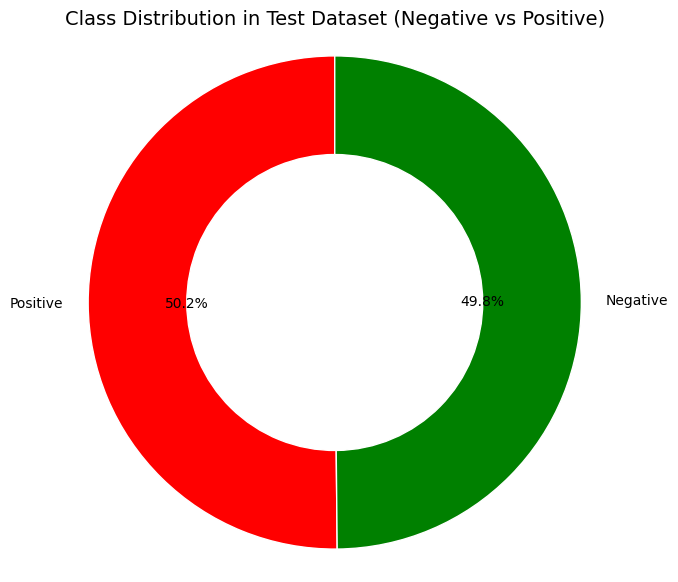

In [ ]:

dist_df = y_test.value_counts().reset_index()
dist_df.columns = ['Sentiment', 'Count']
dist_df['Sentiment'] = dist_df['Sentiment'].map({0: 'Negative', 1: 'Positive'})
plt.figure(figsize=(7, 7))
plt.pie(
    dist_df['Count'],
    labels=dist_df['Sentiment'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['red', 'green'],
    wedgeprops=dict(width=0.4, edgecolor='white')
)
plt.title('Class Distribution in Test Dataset (Negative vs Positive)', fontsize=14)
plt.axis('equal')
plt.show()

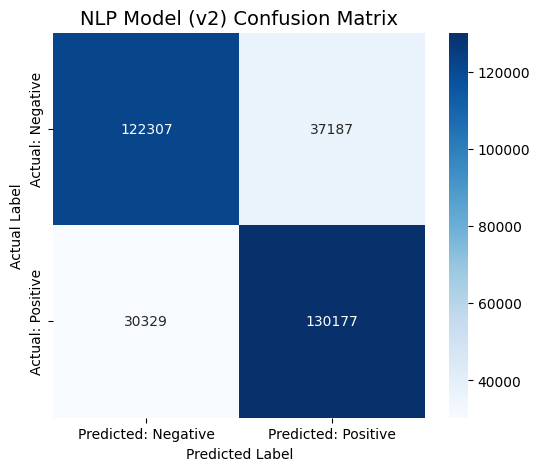

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_v2)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: Negative', 'Predicted: Positive'],
    yticklabels=['Actual: Negative', 'Actual: Positive']
)

plt.title('NLP Model (v2) Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

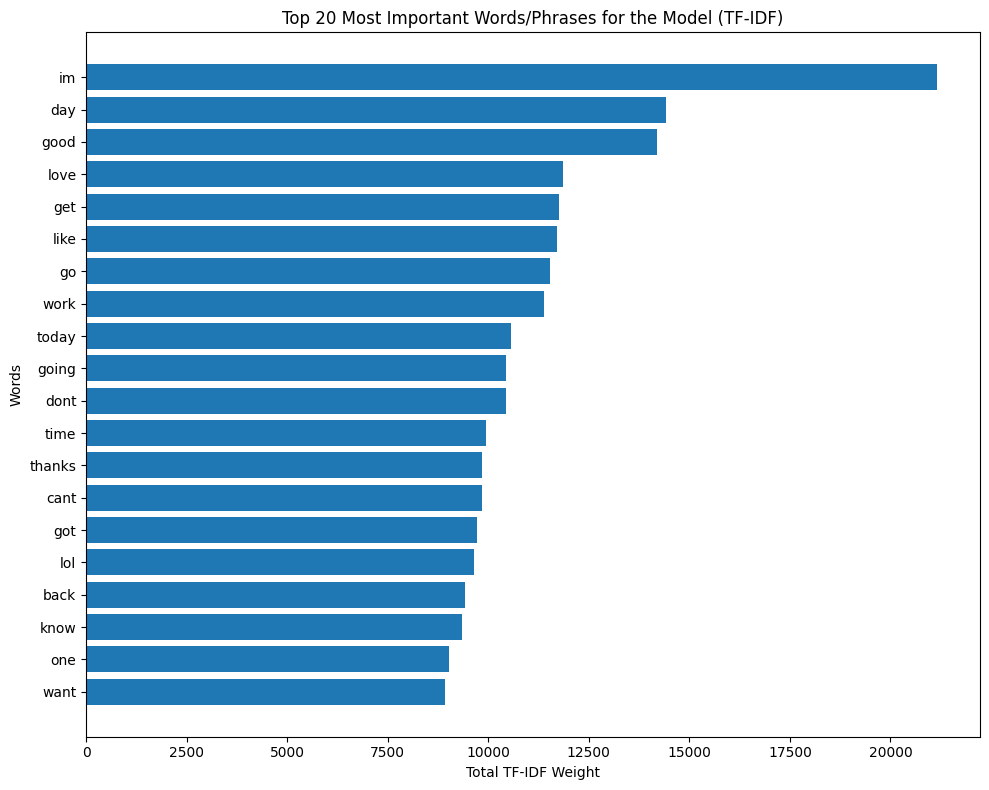

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names and TF-IDF weights
words = vectorizer_v2.get_feature_names_out()
word_weights = np.asarray(X_train_tfidf_v2.sum(axis=0)).flatten()

# Top 20 words
top_indices = word_weights.argsort()[-20:][::-1]

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    words[top_indices][::-1],
    word_weights[top_indices][::-1]
)

plt.xlabel("Total TF-IDF Weight")
plt.ylabel("Words")
plt.title("Top 20 Most Important Words/Phrases for the Model (TF-IDF)")

plt.tight_layout()
plt.show()

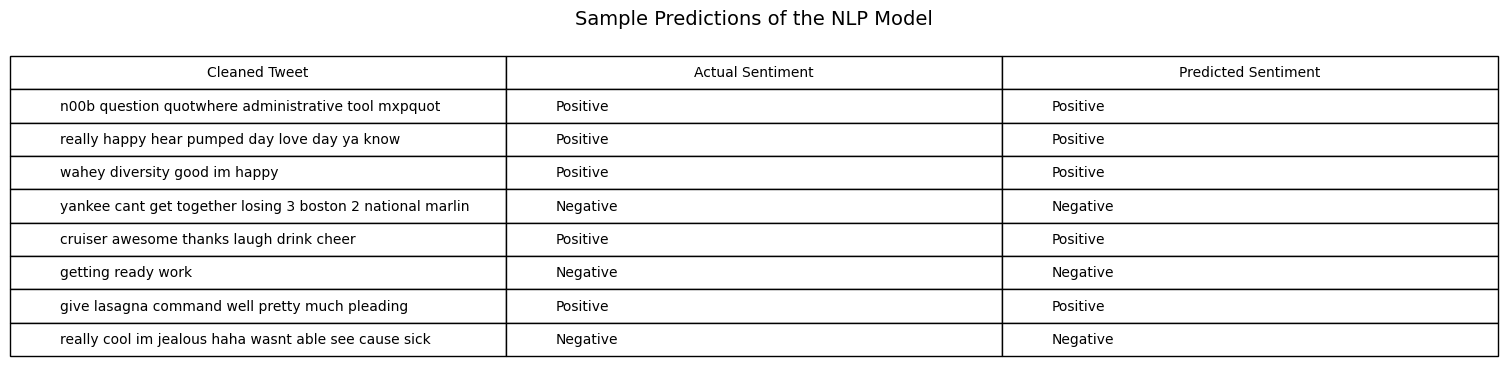

In [62]:

sample_indices = y_test.sample(8, random_state=42).index
sample_texts = X_test.loc[sample_indices]
sample_actuals = y_test.loc[sample_indices].map({0: 'Negative', 1: 'Positive'})

# Get predictions
preds_series = pd.Series(y_pred_v2, index=y_test.index)
sample_preds = preds_series.loc[sample_indices].map({0: 'Negative', 1: 'Positive'})

# Create DataFrame
results_df = pd.DataFrame({
    'Cleaned Tweet': sample_texts,
    'Actual Sentiment': sample_actuals,
    'Predicted Sentiment': sample_preds
})

# Plot table
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    loc='center',
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

plt.title("Sample Predictions of the NLP Model", fontsize=14, pad=20)
plt.show()